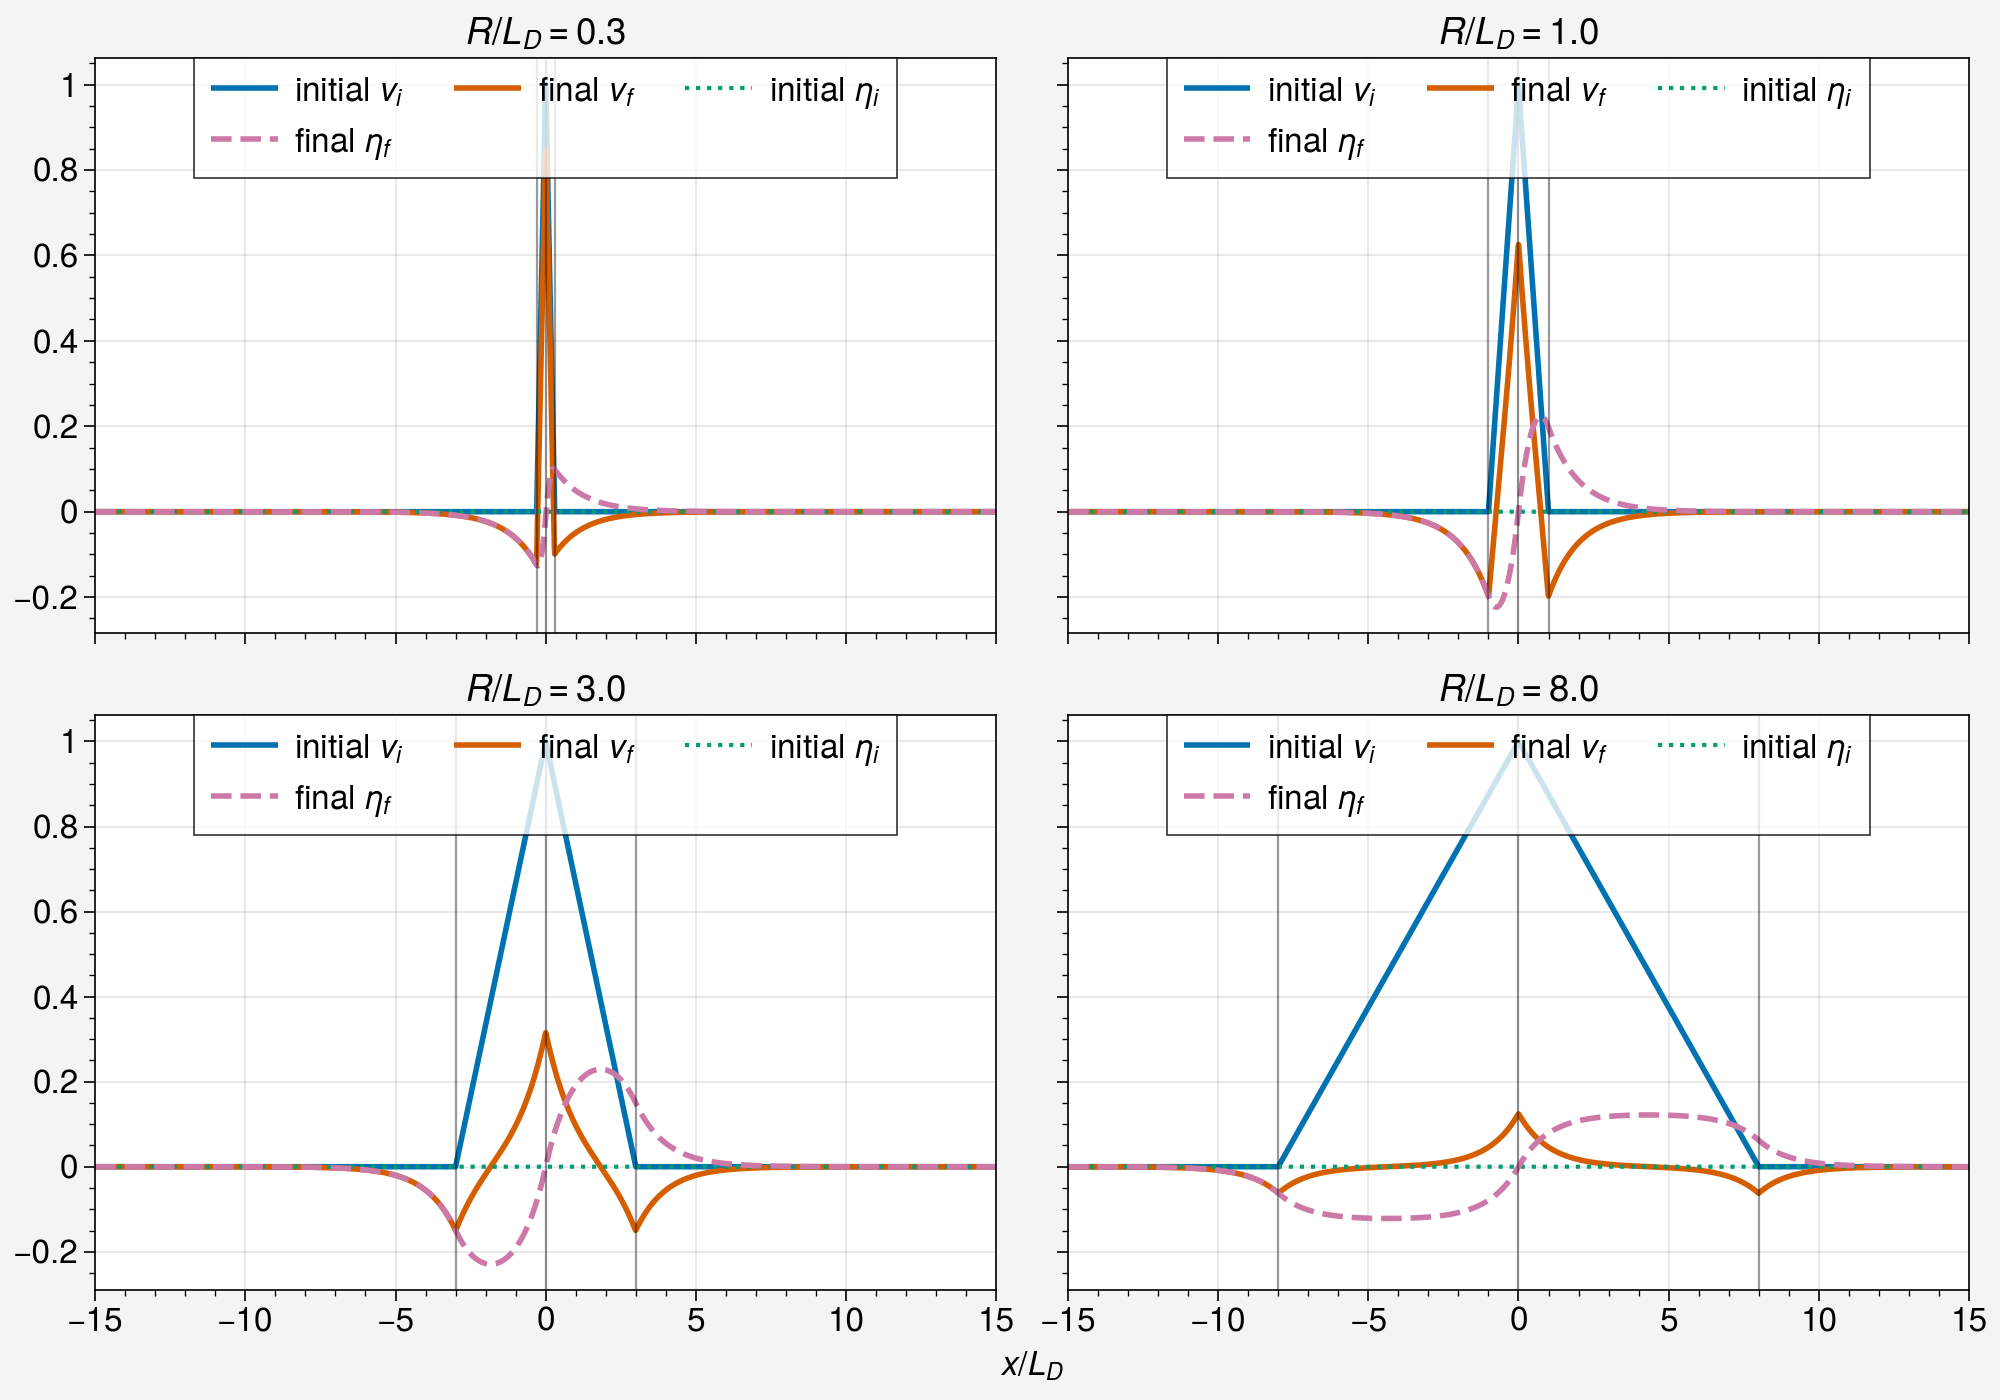

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ultraplot as uplt

# -----------------------------
# Parameters
# -----------------------------
v0 = 1.0
LD = 1.0
f = 1.0
g = 1.0

r_list = [0.3, 1.0, 3.0, 8.0]  # R / LD

# numerical domain
Lbox = 15.0 * LD
nx = 3001
x = np.linspace(-Lbox, Lbox, nx)
dx = x[1] - x[0]

def initial_v(x, R, v0):
    vi = np.zeros_like(x)
    inside = np.abs(x) < R
    vi[inside] = v0 * (R - np.abs(x[inside])) / R
    return vi

def initial_Q(x, R, v0):
    Qi = np.zeros_like(x)
    Qi[(x > -R) & (x < 0)] = v0 / R
    Qi[(x > 0) & (x < R)] = -v0 / R
    return Qi

def solve_eta_fd(x, Qi, LD, f, g):
    """
    Solve eta_xx - eta/LD^2 = (f/g) Qi
    with eta=0 at the two boundaries.
    """
    nx = len(x)
    dx = x[1] - x[0]

    rhs = (f / g) * Qi

    nint = nx - 2
    main = (-2.0 / dx**2 - 1.0 / LD**2) * np.ones(nint)
    off = (1.0 / dx**2) * np.ones(nint - 1)

    A = np.zeros((nint, nint))
    np.fill_diagonal(A, main)
    np.fill_diagonal(A[1:], off)
    np.fill_diagonal(A[:, 1:], off)

    b = rhs[1:-1]

    eta_int = np.linalg.solve(A, b)

    eta = np.zeros(nx)
    eta[1:-1] = eta_int

    return eta

def derivative_centered(y, dx):
    dy = np.zeros_like(y)
    dy[1:-1] = (y[2:] - y[:-2]) / (2.0 * dx)
    dy[0] = (y[1] - y[0]) / dx
    dy[-1] = (y[-1] - y[-2]) / dx
    return dy

# -----------------------------
# Plot
# -----------------------------
fig, axs = uplt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 7),
    sharex=True
)

axs = list(axs)

for ax, r in zip(axs, r_list):
    R = r * LD

    vi = initial_v(x, R, v0)
    etai = np.zeros_like(x)

    Qi = initial_Q(x, R, v0)

    etaf = solve_eta_fd(x, Qi, LD, f, g)
    vf = (g / f) * derivative_centered(etaf, dx)

    ax.plot(x / LD, vi, label=r"initial $v_i$", lw=2)
    ax.plot(x / LD, vf, label=r"final $v_f$", lw=2)
    ax.plot(x / LD, etai, label=r"initial $\eta_i$", lw=1.5, ls=":")
    ax.plot(x / LD, etaf, label=r"final $\eta_f$", lw=2, ls="--")

    ax.axvline(-R / LD, color="k", lw=0.8, alpha=0.4)
    ax.axvline(0, color="k", lw=0.8, alpha=0.4)
    ax.axvline(R / LD, color="k", lw=0.8, alpha=0.4)

    ax.format(
        title=fr"$R/L_D={r}$",
        xlabel=fr"$x/L_D$",
        fontsize=12
    )

    ax.legend(fontsize=12)
    
plt.show()

/tmp/ipykernel_495887/1618331171.py:50: UltraPlotWarning: fig.tight_layout() has no effect on ultraplot figures. ultraplot uses its own tight layout algorithm that is activated by default. To disable it, set uplt.rc['subplots.tight'] to False or pass tight=False to uplt.subplots(). For details, see fig.auto_layout().
  fig.tight_layout()


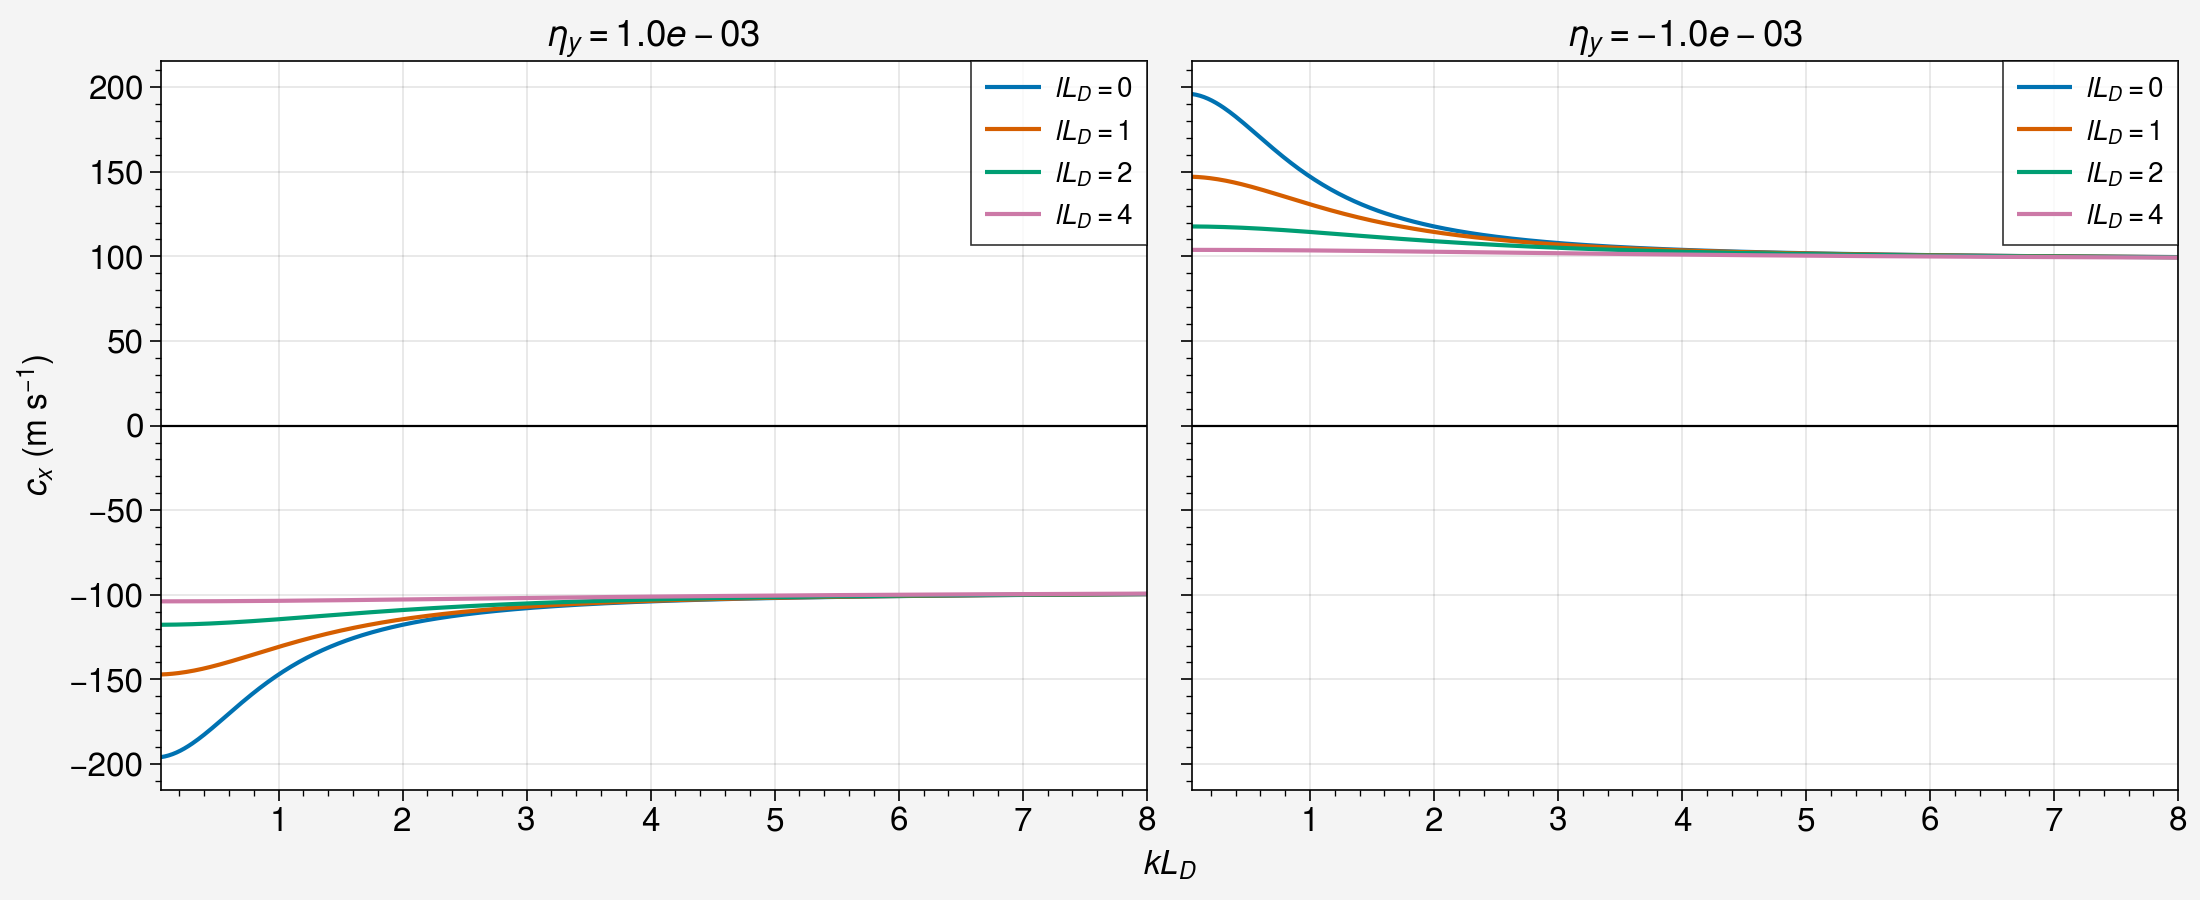

In [ ]:
# -----------------------------
# Parameters
# -----------------------------
g = 9.81
H = 4000.0
f0 = 1.0e-4

LD = np.sqrt(g * H) / f0

# free-surface slopes: positive and negative
eta_y_list = [1.0e-3, -1.0e-3]

# nondimensional zonal wavenumber k*LD
kLD = np.linspace(0.05, 8.0, 500)
k = kLD / LD

# selected meridional wavenumbers, expressed as l*LD
lLD_list = [0.0, 1.0, 2.0, 4.0]

# -----------------------------
# Plot
# -----------------------------
fig, axs = uplt.subplots(
    ncols=2,
    figsize=(11, 4.5),
    sharey=True,
    sharex=True
)

for ax, eta_y in zip(axs, eta_y_list):

    for lLD in lLD_list:
        l = lLD / LD


        # With convention u=-psi_y, v=psi_x:
        cx = (-g * eta_y / f0) + (-f0 * eta_y / H) / (k**2 + l**2 + f0**2 / (g * H))

        ax.plot(kLD, cx, label=fr"$lL_D={lLD:g}$")

    ax.axhline(0, color="k", lw=0.8)
    ax.format(
        title=fr"$\eta_y={eta_y:.1e}$",
        xlabel=fr"$kL_D$",
        ylabel=fr"$c_x$ (m s$^{{-1}}$)",
        fontsize=12
    )
    ax.legend(loc="best", ncols=1, fontsize=10)

fig.tight_layout()
plt.show()